# EN3150 Assignment 03: Simple convolutional neural network to perform classification.



 ## 1 CNN for image classification
 
 In this assignment, you will create a simple image classifier using convolutional neural
 network (CNN). You have the freedom to use any programming language and toolkit of
 your choice, but it is recommended to use the Python programming language along with
 TensorFlow and Keras or PyTorch to construct the convolutional neural network (CNN)

###  1. Set up your environment: Ensure that you have installed all the required software packages.

In [51]:
%pip install torch torchvision matplotlib torchinfo scikit-learn


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: C:\Users\acer\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [64]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torchinfo import summary
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.datasets import ImageFolder
import random
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


BATCH_SIZE,full_dataset,train_dataset

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batchSize = 32

 ### 2. Prepare your dataset: Choose a data set from UCI Machine Learning Repository that is appropriate for classification (Do not use CIFAR-10 dataset). Download the selected dataset

In [66]:
theDataset = ImageFolder(root='Realwaste', transform=transforms.Compose([
    transforms.Resize((131, 131)),
    transforms.ToTensor()
]))


###  3. Split the dataset into training, validation, and testing subsets using a ratio of 60% for training and 20% each for validation and testing sets1

In [67]:
trainDataset, valid_dataset, test_dataset = torch.utils.data.random_split(theDataset, [int(len(theDataset) * 0.6), 
                                                                                          int(len(theDataset) * 0.2), 
                                                                                          len(theDataset) - int(len(theDataset) * 0.6) - int(len(theDataset) * 0.2)])
print(full_dataset.classes)
print(len(full_dataset))
print(len(train_dataset))
print(len(valid_dataset))
print(len(test_dataset))

test_targets = [test_dataset.dataset.targets[i] for i in test_dataset.indices]

['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
4752
2851
950
951


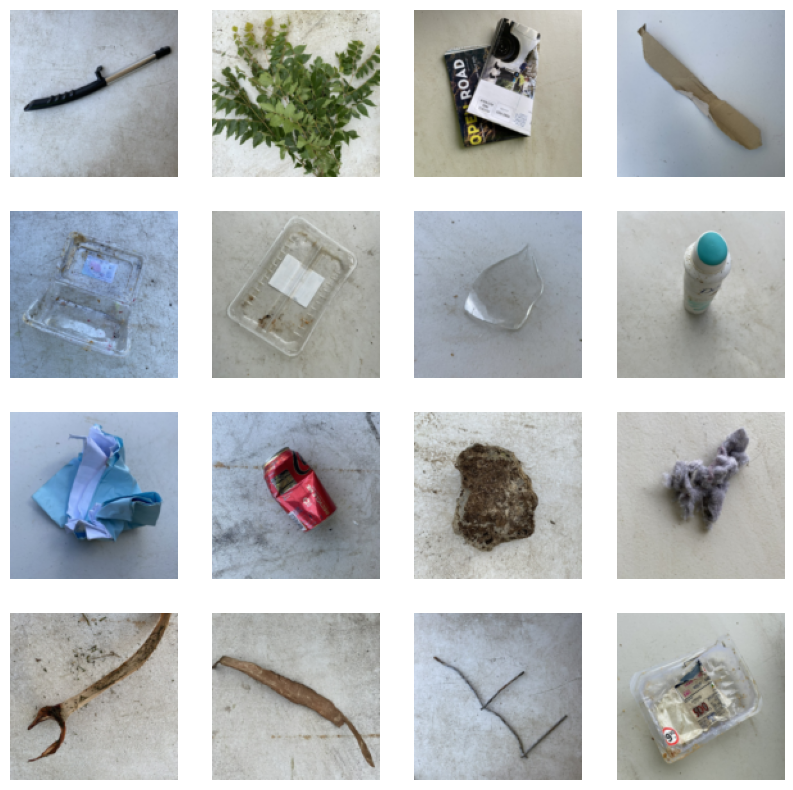

In [68]:
random_indices = random.sample(range(len(trainDataset)), 16)
fig, axs = plt.subplots(4, 4, figsize=(10, 10))
for i, idx in enumerate(random_indices):
    img = trainDataset[idx][0]
    ax = axs[i//4, i%4]
    ax.imshow(img.permute(1, 2, 0))
    ax.axis("off")
plt.show()

In [69]:
train_dataloader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=batchSize, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batchSize, shuffle=False)

### 4. Build the CNN model:

 A common CNN design consists of interleaving convolutional and max-pooling layers, ending with a linear classification layer [1]. This pattern is illustrated in Figure 12, and it was inspired by Fukushima’s neocognitron [2] and Hubel and Wiesel’s work on human visual cortex [3]. Yann LeCun’s LeNet model refined this approach in 1998, popularizing it through backpropagation and SGD [4]. In this example (Figure 1), we exclude normalization layers from the CNN design because the model is relatively simple and not very deep. Here, the benefits of normalization layers may not be visible. However, in deep neural networks, norma ization layers, such as batch normalization or layer normalization, are often used to improve training stability. They help mitigate issues like vanishing gradients and can make it easier for deep networks to converge during training. Refer tensorflow batch normalization and pytorch batch normalization for more information. Abasic CNN architecture is given below. Feel free to modify this network by adding more layers.
 
 • AConvolutional layer with x1 filters, a m1×m1 kernel, and a suitable activation
 function.
 
 • AMaxPooling layer.
 
 • Another Convolutional layer with x2 filters, a m2×m2 kernel, and a suitable
 activation function.
 
 • Another MaxPooling layer.
 
 • Flatten the output.
 
 • Afully connected layer with x3 units and ’a suitable activation function.
 
 • Adddropout with a rate of d to reduce overfitting.
 
 • Anoutput layer with K units (for K classes) and ’softmax’ activation.

 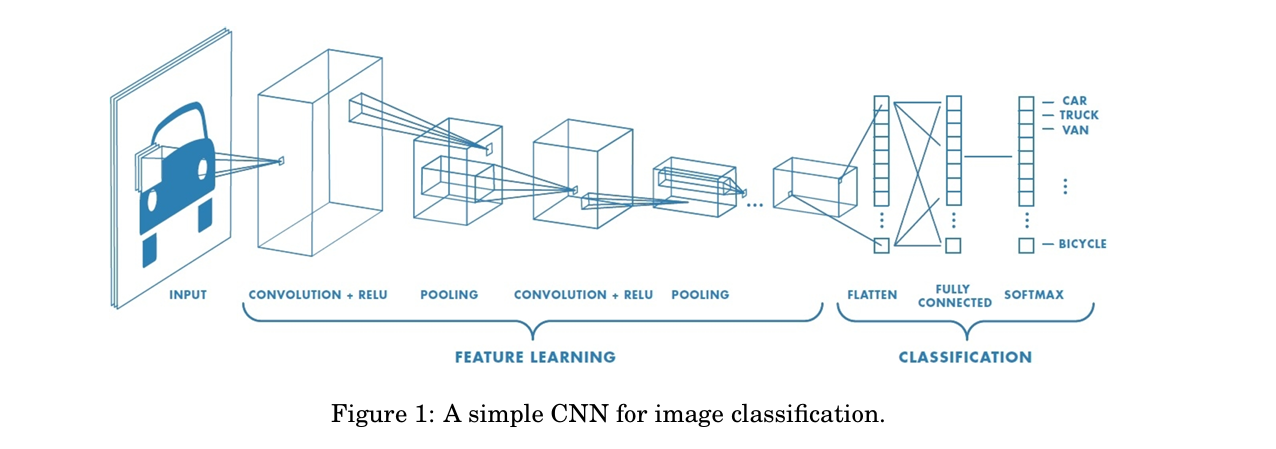

In [70]:
class cnn_model(nn.Module):
    def __init__(self):
        super(cnn_model, self).__init__()
        # First convolutional block: Convolution -> ReLU -> MaxPooling
        self.convblock1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=0), # Convolution layer with 3 input channels and 16 output channels
            nn.ReLU(), # Activation function to introduce non-linearity
            nn.MaxPool2d(2) # Down-sampling with a 2x2 max pooling layer
        )
        # Second convolutional block: Convolution -> ReLU -> MaxPooling
        self.convblock2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=0), # Convolution layer with 16 input channels and 32 output channels
            nn.ReLU(), # Activation function
            nn.MaxPool2d(2) # Down-sampling with a 2x2 max pooling layer
        )
        # Third convolutional block: Convolution -> ReLU -> MaxPooling
        self.convblock3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0), # Convolution layer with 32 input channels and 64 output channels
            nn.ReLU(), # Activation function
            nn.MaxPool2d(2) # Down-sampling with a 2x2 max pooling layer
        )
        # Flattening layer to prepare data for the fully connected layers
        self.flatten = nn.Flatten()
        # Classifier: Fully connected layers with ReLU and Dropout for regularization
        self.classifier = nn.Sequential(
            nn.Linear(64 * 14 * 14, 128), # Fully connected layer reducing dimensions to 128
            nn.ReLU(), # Activation function
            nn.Dropout(0.5), # Dropout to prevent overfitting
            nn.Linear(128, 32), # Fully connected layer reducing dimensions to 32
            nn.ReLU(), # Activation function
            nn.Dropout(0.5), # Dropout to prevent overfitting
            nn.Linear(32, 9) # Final fully connected layer mapping to 9 output classes
        )
        
    def forward(self, x):
        # Pass input through the first convolutional block
        x = self.convblock1(x)
        # Pass input through the second convolutional block
        x = self.convblock2(x)
        # Pass input through the third convolutional block
        x = self.convblock3(x)
        # Flatten the tensor to feed it into the classifier
        x = self.flatten(x)
        # Pass the flattened input through the classifier
        x = self.classifier(x)
        return x

### 5. Determine the parameters of the above network such as activation functions, kernel sizes, filter sizes, size of the fully connected layer and dropout rate.

In [71]:
def train(model:nn.Module,
          trainloader:torch.utils.data.DataLoader,
          testloader:torch.utils.data.DataLoader,
          iterations:int,
          optimizer:torch.optim.Optimizer,
          loss_fn:torch.nn.Module,
          device: torch.device,
          to_print: bool) -> tuple:
    # Lists to keep track of accuracy and loss during training and evaluation
    train_accuracy_hist = [ ]
    test_accuracy_hist = [ ]
    train_loss_hist = [ ]
    test_loss_hist = [ ]
    
    # Main training loop for the specified number of iterations (epochs)
    for t in range(iterations):
        model.train()  # Set the model to training mode
        accuracy = 0  # Initialize train accuracy for this epoch
        running_loss = 0.0  # Initialize train loss for this epoch
        
        # Loop over training data in batches
        for _, data in enumerate(trainloader, 0):
            inputs, labels = data  # Extract input data and labels
            x_train, y_train = inputs.to(device), labels.to(device)  # Move data to the specified device (e.g., GPU)
            y_pred = model(x_train)  # Forward pass: compute model predictions
            loss_val = loss_fn(y_pred, y_train)  # Compute loss between predictions and actual labels
            running_loss += loss_val.item()  # Accumulate loss for this epoch
            optimizer.zero_grad()  # Clear the gradients of the optimizer
            loss_val.backward()  # Backpropagation to compute gradients
            optimizer.step()  # Update model parameters based on gradients
            _, predicted = torch.max(y_pred, 1)  # Get the class with highest predicted probability
            accuracy += (predicted == y_train).sum().item()  # Update accuracy count
        
        # Record training accuracy and loss
        train_accuracy_hist.append(accuracy / len(trainloader.dataset))  # Normalize accuracy by dataset size
        train_loss_hist.append(running_loss / len(trainloader))  # Average loss over all batches
        
        model.eval()  # Set the model to evaluation mode
        with torch.inference_mode():  # Disable gradient computation for evaluation
            accuracy = 0  # Initialize test accuracy for this epoch
            running_loss = 0.0  # Initialize test loss for this epoch
            
            # Loop over testing data in batches
            for i, data in enumerate(testloader, 0):
                inputs, labels = data  # Extract input data and labels
                x_test, y_test = inputs.to(device), labels.to(device)  # Move data to the specified device
                y_pred = model(x_test)  # Forward pass: compute model predictions
                loss_val = loss_fn(y_pred, y_test)  # Compute loss
                running_loss += loss_val.item()  # Accumulate loss for this epoch
                _, predicted = torch.max(y_pred, 1)  # Get the class with highest predicted probability
                accuracy += (predicted == y_test).sum().item()  # Update accuracy count
            
            # Record test accuracy and loss
            test_accuracy_hist.append(accuracy / len(testloader.dataset))  # Normalize accuracy by dataset size
            test_loss_hist.append(running_loss / len(testloader))  # Average loss over all batches
        
        # Print epoch summary if enabled
        if to_print:
            print(f"Epoch {t + 1} / {iterations}, Train Loss: {train_loss_hist[-1]}, Test Loss: {test_loss_hist[-1]}, Train Accuracy: {train_accuracy_hist[-1]}, Test Accuracy: {test_accuracy_hist[-1]}")
    
    # Return training and testing accuracy and loss histories
    return train_accuracy_hist, test_accuracy_hist, train_loss_hist, test_loss_hist

def calculate_accuracy(model: nn.Module, dataloader: torch.utils.data.DataLoader) -> float:
    correct = 0  # Initialize the count of correct predictions
    total = 0  # Initialize the total number of samples
    predictions = []  # List to store all predictions

    with torch.no_grad():  # Disable gradient computation for evaluation
        for data in dataloader:  # Iterate over batches in the dataloader
            inputs, labels = data  # Extract input data and labels
            x, y = inputs.to(device), labels.to(device)  # Move data to the specified device (e.g., GPU)
            outputs = model(x)  # Perform forward pass to get model predictions
            _, predicted = torch.max(outputs, 1)  # Get the class with the highest probability
            predictions.append(predicted)  # Append batch predictions to the list
            total += y.size(0)  # Update the total number of samples
            correct += (predicted == y).sum().item()  # Update the count of correct predictions

    # Calculate accuracy as a percentage
    return 100 * correct / total, torch.cat(predictions)  # Return accuracy and concatenated predictions



In [72]:
model = cnn_model().to(device)
print(summary(cnn_model(), input_size=(batchSize, 3, 131, 131)))

Layer (type:depth-idx)                   Output Shape              Param #
cnn_model                                [32, 9]                   --
├─Sequential: 1-1                        [32, 16, 64, 64]          --
│    └─Conv2d: 2-1                       [32, 16, 129, 129]        448
│    └─ReLU: 2-2                         [32, 16, 129, 129]        --
│    └─MaxPool2d: 2-3                    [32, 16, 64, 64]          --
├─Sequential: 1-2                        [32, 32, 31, 31]          --
│    └─Conv2d: 2-4                       [32, 32, 62, 62]          4,640
│    └─ReLU: 2-5                         [32, 32, 62, 62]          --
│    └─MaxPool2d: 2-6                    [32, 32, 31, 31]          --
├─Sequential: 1-3                        [32, 64, 14, 14]          --
│    └─Conv2d: 2-7                       [32, 64, 29, 29]          18,496
│    └─ReLU: 2-8                         [32, 64, 29, 29]          --
│    └─MaxPool2d: 2-9                    [32, 64, 14, 14]          --
├─Flatt

 ### 6. Provide justifications for activation functions selections.

• ReLU activation function :is widely used in convolutional layers to introduce non-linearity
while maintaining low computational complexity, resulting in faster performance. Its efficiency
stems from the simplicity of its threshold operation. Unlike sigmoid or tanh functions, ReLU
helps mitigate the vanishing gradient problem, ensuring effective gradient propagation during
backpropagation.
• The Softmax activation function: is typically employed in the output layer to convert logits
into probabilities. However, it is not directly applied in the final layer during loss computation.
Instead, it works seamlessly with the commonly used cross-entropy loss function.

 ###  7. Train the model: Train the model using the training data for 20 epochs 
 and plot training and validation loss for with respect to epoch. Here, for the optimizer
 you may use adam and sparse categorical crossentropy as the loss function. Set
 a suitable learning rate. Refer this page to see available optimizers keras opti
mizers and pytorch optimizers. More information about optimizer can be found in
 https://cs231n.github.io/neural-networks.

In [73]:
iterations = 20
loss = nn.CrossEntropyLoss()
model = cnn_model().to(device) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_accuracy_list, test_accuracy_hist, train_loss_hist, test_loss_hist = train(model, train_dataloader, valid_dataloader, iterations, optimizer, loss, device, True)

Epoch 1 / 20, Train Loss: 2.177605026298099, Test Loss: 2.124290188153585, Train Accuracy: 0.1592423710978604, Test Accuracy: 0.26842105263157895
Epoch 2 / 20, Train Loss: 2.0971007227897642, Test Loss: 1.986552619934082, Train Accuracy: 0.22728867064188005, Test Accuracy: 0.2789473684210526
Epoch 3 / 20, Train Loss: 1.9720700263977051, Test Loss: 1.81180073817571, Train Accuracy: 0.27884952648193617, Test Accuracy: 0.36
Epoch 4 / 20, Train Loss: 1.8273602366447448, Test Loss: 1.5931851545969644, Train Accuracy: 0.34479130129779023, Test Accuracy: 0.41368421052631577
Epoch 5 / 20, Train Loss: 1.7531737433539496, Test Loss: 1.5927678068478903, Train Accuracy: 0.3710978603998597, Test Accuracy: 0.4368421052631579
Epoch 6 / 20, Train Loss: 1.6631903383466933, Test Loss: 1.6633991479873658, Train Accuracy: 0.3995089442300947, Test Accuracy: 0.39473684210526316
Epoch 7 / 20, Train Loss: 1.6466016994582282, Test Loss: 1.40859405597051, Train Accuracy: 0.407576289021396, Test Accuracy: 0.4926

 ### 8. Why wehave chosen adam optimizer over SGD?


The Adam optimizer leverages adaptive learning rates, which adjust dynamically based on historical
gradient information. This allows it to achieve faster convergence and produce better solutions, espe-
cially in scenarios where the magnitudes of gradients vary significantly. Unlike Stochastic Gradient
Descent (SGD), where a fixed learning rate must be predefined and remains constant throughout
training, Adam adapts the learning rate for each parameter individually.
A key feature of Adam is gradient scaling, which helps stabilize the training process by accounting
for the magnitude of past gradients. This scaling reduces the likelihood of oscillations or divergence
during backpropagation, making the optimizer more robust to changes in gradient magnitude. As
a result, Adam significantly minimizes the need for manual tuning of the learning rate, a common
challenge when using SGD. This makes it particularly suitable for complex models and datasets
where determining an optimal fixed learning rate is difficult.

 ### 9. Why wehave chosen sparse categorical crossentropy as the loss function?

Sparse Categorical Cross Entropy is a commonly used loss function in multi-class classification
problems. This uses integer encoding which is more efficient when we have a lot of categories or
labels which would consume a huge amount of resources(RAM).

### 10. Evaluate the Model: After training, evaluate the model’s performance on the testing dataset. Record the train/test accuracy, confusion matrix, precision and recall.



  ### 11. Plot training and validation loss for with respect to epoch for different learning rates such as 0.0001, 0.001, 0.01, and 0.1. Comment on your results and select a learning rate with a justification.


Small Learning Rate ( 0.0001)

A very small learning rate results in slower training as the updates to the model parameters are
minimal in each step. Consequently, the loss decreases gradually, which makes the training process
more time-consuming and can delay convergence to the optimal solution.

Large Learning Rate (0.1)

When the learning rate is excessively large, the training and validation losses may oscillate or even
diverge. This occurs because the parameter updates overshoot the optimal point in the loss function,
preventing the model from stabilizing and hindering convergence to a minimum.

Moderate Learning Rate (0.001)

A moderate learning rate offers a balanced approach, allowing the model to update parameters
efficiently while avoiding overshooting the optimal point. This enables faster and more stable con-
vergence, making it an ideal choice for reliable model training.

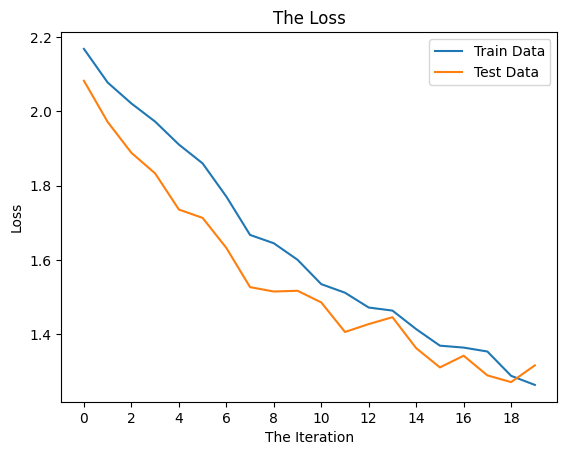

In [46]:
plt.plot(train_loss_hist, label='Train Data')
plt.plot(test_loss_hist, label='Test Data')
plt.xlabel('The Iteration')
plt.ylabel('Loss')
plt.xticks(range(0, iterations, 2))
plt.title('The Loss')
plt.legend()
plt.show()

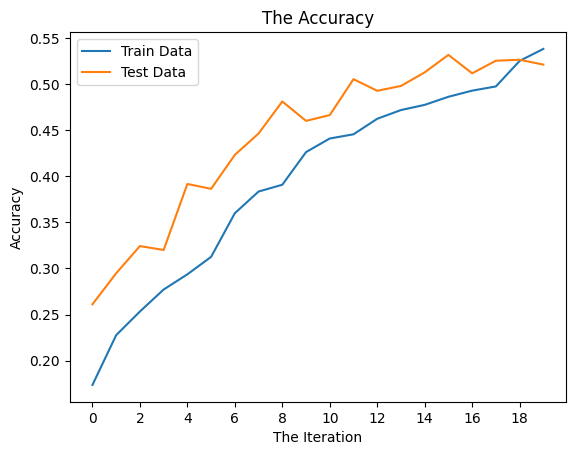

In [47]:
plt.plot(train_accuracy_hist, label='Train Data')
plt.plot(test_accuracy_hist, label='Test Data')
plt.xlabel('The Iteration')
plt.ylabel('Accuracy')
plt.xticks(range(0, iterations, 2))
plt.title('The Accuracy')
plt.legend()
plt.show()

Test accuracy: 8.412197686645635%


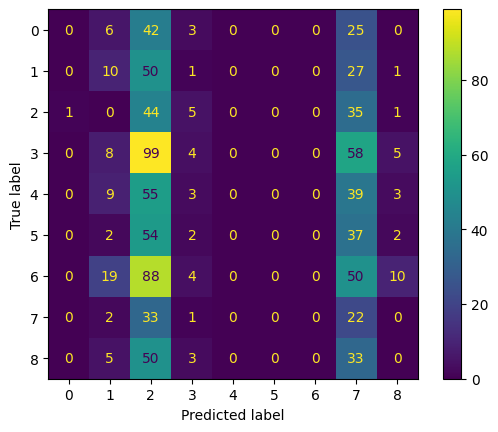

In [48]:
test_accuracy, test_predictions = calculate_accuracy(model, test_dataloader)
print(f"Test accuracy: {test_accuracy}%")

cm = confusion_matrix(test_targets, test_predictions.cpu())
ConfusionMatrixDisplay(cm).plot()

In [49]:
train_accuracy,_ = calculate_accuracy(model, train_dataloader)

print(f"Train accuracy: {train_accuracy:.2f}%")
print(f"Test accuracy: {test_accuracy:.2f}%")

Train accuracy: 8.63%
Test accuracy: 8.41%


In [50]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]  # Define a list of learning rates to test
iterations = 20  # Number of training epochs for each learning rate
train_accuracy_history_lr = []  # List to store the final training accuracy for each learning rate
test_accuracy_history_lr = []  # List to store the final testing accuracy for each learning rate
loss = nn.CrossEntropyLoss()  # Define the loss function (CrossEntropyLoss for classification)

# Iterate over each learning rate
for learning_rate in learning_rates:
    model = cnn_model().to(device)  # Initialize and reset the model for each learning rate
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.0001)  # Define the optimizer with the current learning rate and weight decay

    # Train the model and capture accuracy and loss histories
    train_accuracy_list, test_accuracy_hist, train_loss_hist, test_loss_hist = train(
        model,  # Model to train
        train_dataloader,  # Training data loader
        test_dataloader,  # Testing data loader
        iterations,  # Number of epochs
        optimizer,  # Optimizer
        loss,  # Loss function
        device,  # Device (e.g., GPU or CPU)
        False  # Suppress printing epoch-level metrics
    )

    # Append the final accuracy values for training and testing to respective lists
    train_accuracy_history_lr.append(train_accuracy_list[-1])  # Take the last recorded training accuracy
    test_accuracy_history_lr.append(test_accuracy_hist[-1])  # Take the last recorded testing accuracy

    # Print the learning rate and the corresponding final training and testing accuracies
    print(f"Learning Rate: {learning_rate}, Train Accuracy: {train_accuracy_list[-1]}, Test Accuracy: {test_accuracy_hist[-1]}")

KeyboardInterrupt: 

## 2 Compareyournetwork with state-of-the-art networks

 "In practice, training an entire convolutional network from scratch (starting with
 random initialization) is a rare occurrence. This is primarily due to the scarcity of
 datasets of sufficient size. Instead, a common approach is to first pretrain a CNN
 on an extensive dataset, such as ImageNet, which comprises 1.2 million images
 across 1000 categories. Subsequently, this pretrained CNN can be utilized as either
 an initialization point or a fixed feature extractor when tackling a specific task of
 interest. This is known as transfer learning" 3

### 12. Choose two state-of-the-art pre-trained model or architecture like ImageNet, ResNet, Googlenet, AlexNet, DenseNet and VGG

## Resnet

 13. Load the pre-trained model and fine-tune it for the your dataset.
 14. Train the fine-tuned model using the same training and testing data splits as your
 custom CNN model.
 15. Record training and validation loss values for each epoch.
 16. Evaluate the fine-tuned model on the testing dataset and calculate the test accuracy.
 17. Compare the test accuracy of your custom CNN model with that of the fine-tuned
 state-of-the-art model

In [43]:
resnet_model = torchvision.models.resnet18(weights = 'IMAGENET1K_V1').to(device) # These are the default weights
print(summary(resnet_model, input_size=(batchSize, 3, 524, 524), col_names=("input_size", "output_size", "num_params", "trainable")))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ResNet                                   [32, 3, 524, 524]         [32, 1000]                --                        True
├─Conv2d: 1-1                            [32, 3, 524, 524]         [32, 64, 262, 262]        9,408                     True
├─BatchNorm2d: 1-2                       [32, 64, 262, 262]        [32, 64, 262, 262]        128                       True
├─ReLU: 1-3                              [32, 64, 262, 262]        [32, 64, 262, 262]        --                        --
├─MaxPool2d: 1-4                         [32, 64, 262, 262]        [32, 64, 131, 131]        --                        --
├─Sequential: 1-5                        [32, 64, 131, 131]        [32, 64, 131, 131]        --                        True
│    └─BasicBlock: 2-1                   [32, 64, 131, 131]        [32, 64, 131, 131]        --                        True
│    │ 

In [44]:
resnet_model.fc = nn.Linear(in_features=512, out_features=9, bias=True).to(device)
print(resnet_model.fc)

Linear(in_features=512, out_features=9, bias=True)


In [45]:
print(summary(resnet_model, input_size=(batchSize, 3, 131, 131), col_names=("input_size", "output_size", "num_params", "trainable")))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ResNet                                   [32, 3, 131, 131]         [32, 9]                   --                        True
├─Conv2d: 1-1                            [32, 3, 131, 131]         [32, 64, 66, 66]          9,408                     True
├─BatchNorm2d: 1-2                       [32, 64, 66, 66]          [32, 64, 66, 66]          128                       True
├─ReLU: 1-3                              [32, 64, 66, 66]          [32, 64, 66, 66]          --                        --
├─MaxPool2d: 1-4                         [32, 64, 66, 66]          [32, 64, 33, 33]          --                        --
├─Sequential: 1-5                        [32, 64, 33, 33]          [32, 64, 33, 33]          --                        True
│    └─BasicBlock: 2-1                   [32, 64, 33, 33]          [32, 64, 33, 33]          --                        True
│    │ 

In [46]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet_model.parameters(), lr = 0.001, weight_decay = 0.001)
iterations = 20

In [47]:
train_accuracy_hist, test_accuracy_hist, train_loss_hist, test_loss_hist = train(resnet_model, train_dataloader, valid_dataloader, iterations, optimizer, loss, device, True)

Epoch 1 / 20, Train Loss: 1.2572589072916243, Test Loss: 1.2665621519088746, Train Accuracy: 0.5580498070852332, Test Accuracy: 0.5726315789473684
Epoch 2 / 20, Train Loss: 0.9704642706447177, Test Loss: 1.5256344477335613, Train Accuracy: 0.6478428621536303, Test Accuracy: 0.5178947368421053
Epoch 3 / 20, Train Loss: 1.0215985119342803, Test Loss: 2.1790023922920225, Train Accuracy: 0.6601192564012627, Test Accuracy: 0.48526315789473684
Epoch 4 / 20, Train Loss: 0.7443489909172059, Test Loss: 1.2106615881125131, Train Accuracy: 0.7471062784987723, Test Accuracy: 0.6
Epoch 5 / 20, Train Loss: 0.6428454435533948, Test Loss: 1.3087791085243226, Train Accuracy: 0.7804279200280604, Test Accuracy: 0.6189473684210526
Epoch 6 / 20, Train Loss: 0.5262662344508701, Test Loss: 1.2448945800463358, Train Accuracy: 0.8235706769554543, Test Accuracy: 0.6389473684210526
Epoch 7 / 20, Train Loss: 0.5615802865889338, Test Loss: 1.3070878724257151, Train Accuracy: 0.8067344791301297, Test Accuracy: 0.57

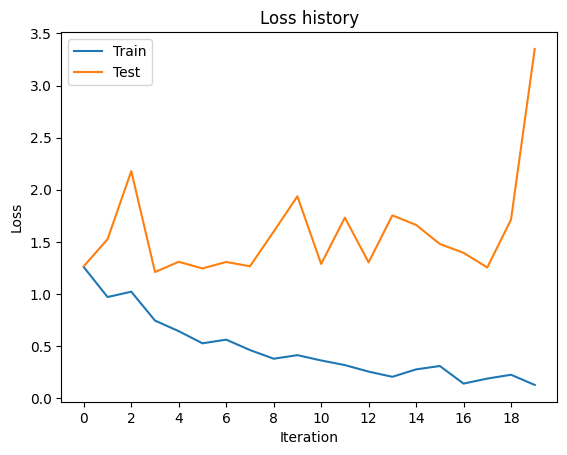

In [48]:
plt.plot(train_loss_hist, label='Train Data')
plt.plot(test_loss_hist, label='Test Data')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.xticks(range(0, iterations, 2))
plt.title('The Loss')
plt.legend()
plt.show()

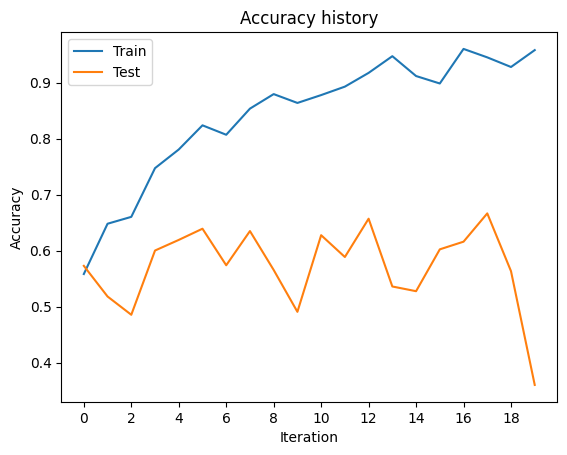

In [49]:
plt.plot(train_accuracy_hist, label='Train Data')
plt.plot(test_accuracy_hist, label='Test Data')
plt.xlabel('The Iterations')
plt.ylabel('Accuracy')
plt.xticks(range(0, iterations, 2))
plt.title('The Accuracy')
plt.legend()
plt.show()

Test accuracy: 32.17665615141956%


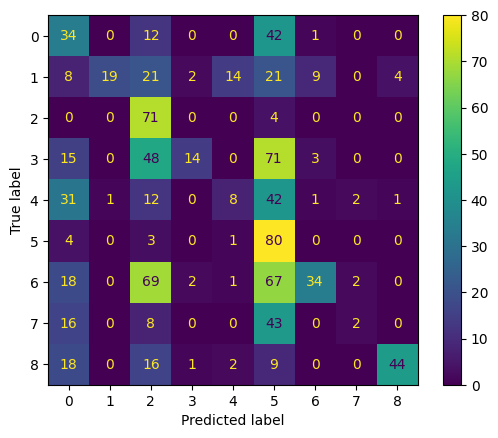

In [50]:
test_accuracy, test_predictions = calculate_accuracy(resnet_model, test_dataloader)
print(f"Test accuracy: {test_accuracy}%")

cm = confusion_matrix(test_targets, test_predictions.cpu())
ConfusionMatrixDisplay(cm).plot()

In [51]:
train_accuracy,_ = calculate_accuracy(resnet_model, train_dataloader)
test_accuracy,_ = calculate_accuracy(resnet_model, test_dataloader)

print(f"Train accuracy: {train_accuracy:.2f}%")
print(f"Test accuracy: {test_accuracy:.2f}%")

Train accuracy: 51.42%
Test accuracy: 32.18%


### 12. Choose two state-of-the-art pre-trained model or architecture like ImageNet, ResNet, Googlenet, AlexNet, DenseNet and VGG

## VGG

 13. Load the pre-trained model and fine-tune it for the your dataset.
 14. Train the fine-tuned model using the same training and testing data splits as your
 custom CNN model.
 15. Record training and validation loss values for each epoch.
 16. Evaluate the fine-tuned model on the testing dataset and calculate the test accuracy.
 17. Compare the test accuracy of your custom CNN model with that of the fine-tuned
 state-of-the-art model

In [17]:
vgg_model = torchvision.models.vgg16(weights = torchvision.models.VGG16_Weights).to(device) # These are the default weights
print(summary(vgg_model, input_size=(batchSize, 3, 131, 131), col_names=("input_size", "output_size", "num_params", "trainable")))

c:\Users\warre\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
VGG                                      [32, 3, 131, 131]         [32, 1000]                --                        True
├─Sequential: 1-1                        [32, 3, 131, 131]         [32, 512, 4, 4]           --                        True
│    └─Conv2d: 2-1                       [32, 3, 131, 131]         [32, 64, 131, 131]        1,792                     True
│    └─ReLU: 2-2                         [32, 64, 131, 131]        [32, 64, 131, 131]        --                        --
│    └─Conv2d: 2-3                       [32, 64, 131, 131]        [32, 64, 131, 131]        36,928                    True
│    └─ReLU: 2-4                         [32, 64, 131, 131]        [32, 64, 131, 131]        --                        --
│    └─MaxPool2d: 2-5                    [32, 64, 131, 131]        [32, 64, 65, 65]          --                        --
│    └─Co

In [18]:
vgg_model.classifier[6] = nn.Linear(in_features=4096, out_features=9, bias=True).to(device)

In [19]:
print(summary(vgg_model, input_size=(batchSize, 3, 131, 131), col_names=("input_size", "output_size", "num_params", "trainable")))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
VGG                                      [32, 3, 131, 131]         [32, 9]                   --                        True
├─Sequential: 1-1                        [32, 3, 131, 131]         [32, 512, 4, 4]           --                        True
│    └─Conv2d: 2-1                       [32, 3, 131, 131]         [32, 64, 131, 131]        1,792                     True
│    └─ReLU: 2-2                         [32, 64, 131, 131]        [32, 64, 131, 131]        --                        --
│    └─Conv2d: 2-3                       [32, 64, 131, 131]        [32, 64, 131, 131]        36,928                    True
│    └─ReLU: 2-4                         [32, 64, 131, 131]        [32, 64, 131, 131]        --                        --
│    └─MaxPool2d: 2-5                    [32, 64, 131, 131]        [32, 64, 65, 65]          --                        --
│    └─Co

In [20]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vgg_model.parameters(), lr = 0.001, weight_decay = 0.001)
iterations = 20

In [21]:
train_accuracy_hist, test_accuracy_hist, train_loss_hist, test_loss_hist = train(vgg_model, train_dataloader, valid_dataloader, iterations, optimizer, loss, device, True)

Epoch 1 / 20, Train Loss: 2.248660537931654, Test Loss: 2.062850844860077, Train Accuracy: 0.17222027358821465, Test Accuracy: 0.22631578947368422
Epoch 2 / 20, Train Loss: 1.9470009830262927, Test Loss: 1.8513290166854859, Train Accuracy: 0.26797614871974745, Test Accuracy: 0.25684210526315787
Epoch 3 / 20, Train Loss: 1.8087235755390592, Test Loss: 1.787570635477702, Train Accuracy: 0.31673097158891617, Test Accuracy: 0.3273684210526316
Epoch 4 / 20, Train Loss: 1.6324538853433397, Test Loss: 1.7193208813667298, Train Accuracy: 0.3952998947737636, Test Accuracy: 0.3778947368421053
Epoch 5 / 20, Train Loss: 1.550548379951053, Test Loss: 1.5139518618583678, Train Accuracy: 0.4279200280603297, Test Accuracy: 0.44842105263157894
Epoch 6 / 20, Train Loss: 1.5394657909870149, Test Loss: 1.6208757599194845, Train Accuracy: 0.4373903893370747, Test Accuracy: 0.4073684210526316
Epoch 7 / 20, Train Loss: 1.384140564997991, Test Loss: 1.6008416374524435, Train Accuracy: 0.4766748509294984, Test

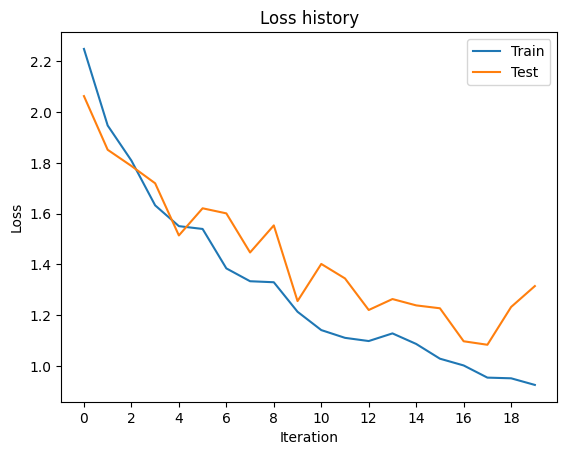

In [22]:
plt.plot(train_loss_hist, label='Train Data')
plt.plot(test_loss_hist, label='Test Data')
plt.xlabel('The Iterations')
plt.ylabel('Loss')
plt.xticks(range(0, iterations, 2))
plt.title('The Loss')
plt.legend()
plt.show()

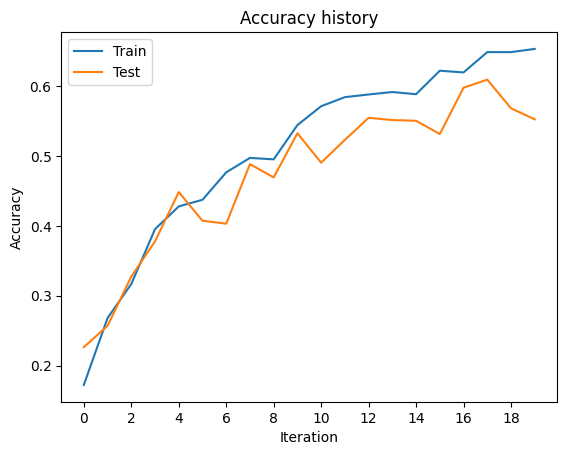

In [23]:
plt.plot(train_accuracy_hist, label='Train Data')
plt.plot(test_accuracy_hist, label='Test Data')
plt.xlabel('The Iterations')
plt.ylabel('Accuracy')
plt.xticks(range(0, iterations, 2))
plt.title('The Accuracy')
plt.legend()
plt.show()

Test accuracy: 55.310199789695055%


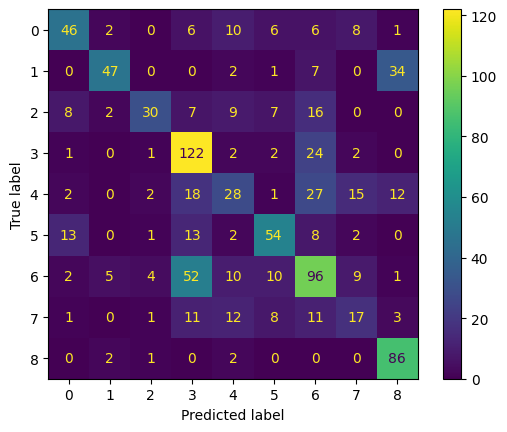

In [24]:
test_accuracy, test_predictions = calculate_accuracy(vgg_model, test_dataloader)
print(f"Test accuracy: {test_accuracy}%")

cm = confusion_matrix(test_targets, test_predictions.cpu())
ConfusionMatrixDisplay(cm).plot()

In [25]:
train_accuracy,_ = calculate_accuracy(vgg_model, train_dataloader)
test_accuracy,_ = calculate_accuracy(vgg_model, test_dataloader)

print(f"Train accuracy: {train_accuracy:.2f}%")
print(f"Test accuracy: {test_accuracy:.2f}%")

Train accuracy: 65.87%
Test accuracy: 55.31%


### 18. Discuss trade-offs, advantages, and limitations of using a custom model versus a pre-trained model.


Test accuracy is highest in VGG-16, But lower in Resnet-18 than custom model

2.3 trade-offs, advantages, and limitations of using a custom model versus
a pre-trained model

In deep learning, selecting between a custom model and a pre-trained model depends on several
factors such as the available dataset, computational resources, and the specific task. Both approaches
have their own advantages and limitations.

2.3.1 Custom Models
A custom model is designed and trained from scratch for a specific task. This allows for greater
flexibility but comes with certain challenges.
Advantages of Custom Models
• Tailored for the Task: Custom models can be specifically designed to meet the requirements
of the given problem, allowing for greater adaptability.
• No Dependency on Large Datasets: Custom models are suitable for tasks where you
have a smaller, domain-specific dataset that does not align with the datasets used to train

pre-trained models.
• Full Control Over Architecture: Since the model is built from the ground up, you have
complete control over the architecture and can experiment with different designs.

Limitations of Custom Models
• Data Requirements: Custom models typically require large amounts of data to achieve good
performance. A lack of sufficient data may lead to poor generalization and overfitting.
• High Training Cost: Training custom models from scratch is computationally expensive
and time-consuming, often requiring powerful hardware and extended training periods.
• Risk of Poor Generalization: If the data is limited or not diverse enough, the model may
struggle to generalize to new, unseen data.

Pre-trained Models
Pre-trained models are trained on large datasets and can be fine-tuned for a specific task, saving
time and resources.

Advantages of Pre-trained Models
• Reduced Training Time: Pre-trained models require much less time to train. Fine-tuning
only involves adjusting the final layers to adapt the model to the new task.
• Better Performance with Less Data: Since pre-trained models have already learned useful
features from large datasets, they can perform well even with smaller datasets.
• Lower Resource Requirements: Fine-tuning a pre-trained model requires less computa-
tional power compared to training a model from scratch.
• Improved Generalization: Pre-trained models typically generalize better as they are trained
on large, diverse datasets.
13

Limitations of Pre-trained Models
• Domain Mismatch: If the pre-trained model was trained on data that is very different from
your specific domain (e.g., medical images), performance may be suboptimal.
• Limited Flexibility: The architecture of a pre-trained model is fixed, and you may not be
able to customize it entirely for very specific tasks.
• Overfitting with Small Data: When fine-tuning a pre-trained model on a very small
dataset, there is a risk of overfitting, especially if the model is large